<a href="https://colab.research.google.com/github/jaityagi63/ml_scratch/blob/master/kmeansregres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [3]:
data = load_diabetes()

In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [5]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [6]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('target',axis=1),df['target'] )

In [7]:
x_train.shape

(331, 10)

In [8]:
x_test.shape

(111, 10)

In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
knn = KNeighborsRegressor(n_neighbors=12, weights='distance', metric='minkowski', p=1)
knn.fit(x_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=12, p=1, weights='distance')

In [11]:
y_pred = knn.predict(x_test_scaled)

In [12]:
print(r2_score(y_test,y_pred))

0.45103764379515365


###for low value of neighbour --> overfitting
###for high value of neighbour --> underfitting

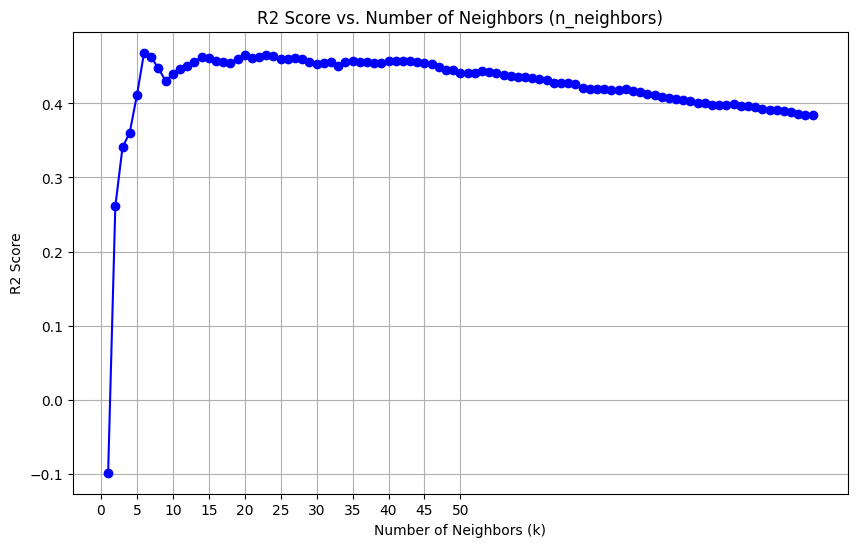

Maximum R2 Score: 0.4684 at k = 6


In [13]:
import matplotlib.pyplot as plt

neighbors = range(1, 100)
r2_scores = []

for k in neighbors:
    model = KNeighborsRegressor(n_neighbors=k, weights='distance', metric='minkowski', p=1)
    model.fit(x_train_scaled, y_train)
    y_val_pred = model.predict(x_test_scaled)
    r2_scores.append(r2_score(y_test, y_val_pred))

plt.figure(figsize=(10, 6))
plt.plot(neighbors, r2_scores, marker='o', linestyle='-', color='b')
plt.title('R2 Score vs. Number of Neighbors (n_neighbors)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R2 Score')
plt.grid(True)
plt.xticks(range(0, 51, 5))
plt.show()

print(f'Maximum R2 Score: {max(r2_scores):.4f} at k = {neighbors[np.argmax(r2_scores)]}')

class from cratch only using the numpy

---



In [47]:
class knnRegressor:
    def __init__(self, n_neighbour):
        self.n_neighbour = n_neighbour
        self.x_train = None
        self.y_train = None

    def fit(self, x_train, y_train):
        self.x_train = x_train.values
        self.y_train = y_train.values

    def predict(self, x_test):
        y_pred = []
        x_test_np = x_test.values
        for test_point in x_test_np:
            distances = []
            for j, train_point in enumerate(self.x_train):
                distance = np.linalg.norm(test_point - train_point)
                distances.append((distance, self.y_train[j]))

            distances.sort(key=lambda x: x[0])

            k_nearest = distances[:self.n_neighbour]

            avg_value = np.mean([val for _, val in k_nearest])
            y_pred.append(avg_value)

        return np.array(y_pred)

In [48]:
knn = knnRegressor(n_neighbour=12)
knn.fit(x_train, y_train)

In [49]:
y_pred = knn.predict(x_test)

In [50]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 204 to 355
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     331 non-null    float64
 1   sex     331 non-null    float64
 2   bmi     331 non-null    float64
 3   bp      331 non-null    float64
 4   s1      331 non-null    float64
 5   s2      331 non-null    float64
 6   s3      331 non-null    float64
 7   s4      331 non-null    float64
 8   s5      331 non-null    float64
 9   s6      331 non-null    float64
dtypes: float64(10)
memory usage: 28.4 KB


In [51]:
print(r2_score(y_test,y_pred))

0.4901797562830946


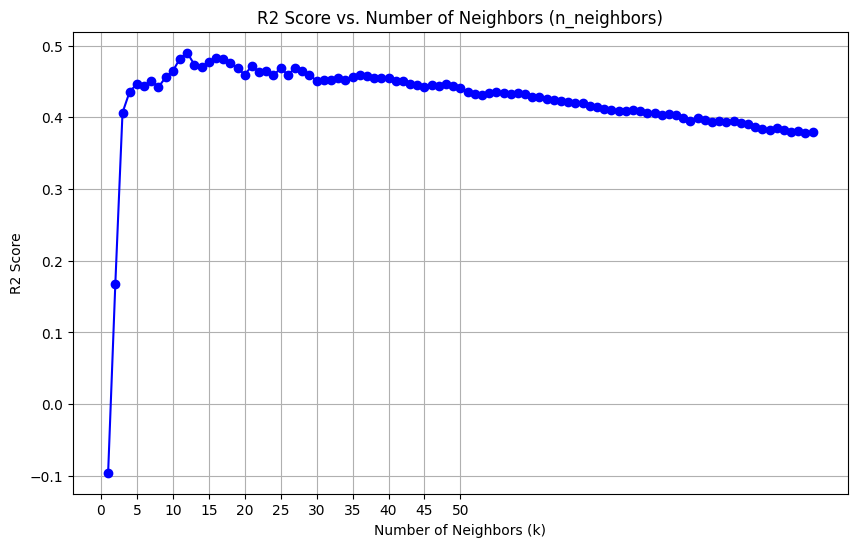

Maximum R2 Score: 0.4902 at k = 12


In [56]:
import matplotlib.pyplot as plt

neighbors = range(1, 100)
r2_scores = []

for k in neighbors:
    model = knnRegressor(n_neighbour=k)
    model.fit(x_train, y_train)
    y_val_pred = model.predict(x_test)
    r2_scores.append(r2_score(y_test, y_val_pred)) # Corrected to use y_val_pred

plt.figure(figsize=(10, 6))
plt.plot(neighbors, r2_scores, marker='o', linestyle='-', color='b')
plt.title('R2 Score vs. Number of Neighbors (n_neighbors)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R2 Score')
plt.grid(True)
plt.xticks(range(0, 51, 5))
plt.show()

print(f'Maximum R2 Score: {max(r2_scores):.4f} at k = {neighbors[np.argmax(r2_scores)]}')